# EDA — Montgomery County Chest X-ray Set (Tuberculosis, External Test)

**Source:** Jaeger et al. 2014 / Candemir et al. 2014, part of the "Pulmonary
Chest X-ray Abnormalities" collection — Kaggle slug
`kmader/pulmonary-chest-xray-abnormalities`. Collected by the Montgomery County
Department of Health and Human Services, Maryland, USA, in collaboration with
NLM/NIH.

**Population:** adult patients — a different country/health system than Shenzhen,
which is exactly why this source is reserved for **external validation** rather
than training.

**Raw layout on disk:**
```
data/raw/pulmonary_abnormalities/Montgomery/MontgomerySet/
├── CXR_png/                      <- the actual X-ray images (what we want)
│   └── MCUCXR_{id}_{label}.png
└── ManualMask/
    ├── leftMask/{id}.png         <- lung segmentation masks, NOT X-rays
    └── rightMask/{id}.png        <- lung segmentation masks, NOT X-rays
```

**Important note on this notebook:** an earlier version of `src/data/prepare.py`
used an unrestricted recursive glob (`rglob("*.png")`) over the whole Montgomery
tree. Because `ManualMask/leftMask/` and `ManualMask/rightMask/` contain files
named with the *same* `MCUCXR_{id}_{label}.png` pattern as the real X-rays, they
were silently parsed as if they were chest X-ray images — inflating the manifest
from 138 real images to 414 rows, two-thirds of which were actually binary lung
masks mislabeled as X-rays. This was caught during a data-quantity audit and
fixed by restricting the parser to `CXR_png/` only. This notebook independently
re-derives that same finding from scratch, as a permanent sanity check.

**This notebook is EDA only.** No files are written out.

**How this dataset will be used in the project:**
- Held out **entirely** as the external / held-out-source test set for the
  `Tuberculosis` class — per `CLAUDE.md` §3 pillar 3 and `DATA.md` §1, this is
  the dataset that answers "does the model generalize, or did it just memorize
  Shenzhen's hospital/scanner signature?"
- **Never used for training or hyperparameter tuning.**

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image

# --- Categorical palette (validated for colorblind-safety, see dataviz skill) ---
PALETTE = {
    "blue":    "#2a78d6",
    "orange":  "#eb6834",
    "aqua":    "#1baf7a",
    "yellow":  "#eda100",
    "magenta": "#e87ba4",
    "green":   "#008300",
    "violet":  "#4a3aa7",
    "red":     "#e34948",
}
CAT_ORDER = ["blue", "orange", "aqua", "yellow", "magenta", "green", "violet", "red"]
CAT_COLORS = [PALETTE[k] for k in CAT_ORDER]

INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"

sns.set_theme(style="white", rc={
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

def load_rgb(path, max_side=None):
    """Load an image as RGB uint8 array (grayscale/16-bit safe)."""
    img = Image.open(path).convert("RGB")
    if max_side:
        img.thumbnail((max_side, max_side))
    return np.array(img)

print("Setup OK. Palette + helpers loaded.")

Setup OK. Palette + helpers loaded.


## 1. Reproduce the mask-contamination bug, then fix it

First we show what happens with an unrestricted recursive glob (the old, buggy
behavior), then restrict to `CXR_png/` only (the corrected behavior actually used
in `src/data/prepare.py` today).

In [ ]:
MONTGOMERY_DIR = Path("../data/raw/pulmonary_abnormalities/Montgomery/MontgomerySet")

all_pngs = [p for p in MONTGOMERY_DIR.rglob("*.png") if "__MACOSX" not in str(p) and not p.name.startswith("._")]
by_parent = Counter(p.parent.name for p in all_pngs)

print("PNG file count by parent folder (unrestricted rglob):")
for parent, n in sorted(by_parent.items(), key=lambda kv: -kv[1]):
    print(f"  {parent:12s}: {n}")

cxr_pngs = [p for p in all_pngs if p.parent.name == "CXR_png"]
print(f"\nTotal PNGs anywhere:        {len(all_pngs)}")
print(f"PNGs inside CXR_png/ only:  {len(cxr_pngs)}  <-- the real X-ray count")
print(f"Mask files that would have been misparsed as X-rays: {len(all_pngs) - len(cxr_pngs)}")

PNG file count by parent folder (unrestricted rglob):
  CXR_png     : 138
  leftMask    : 138
  rightMask   : 138

Total PNGs anywhere:        414
PNGs inside CXR_png/ only:  138  <-- the real X-ray count
Mask files that would have been misparsed as X-rays: 276


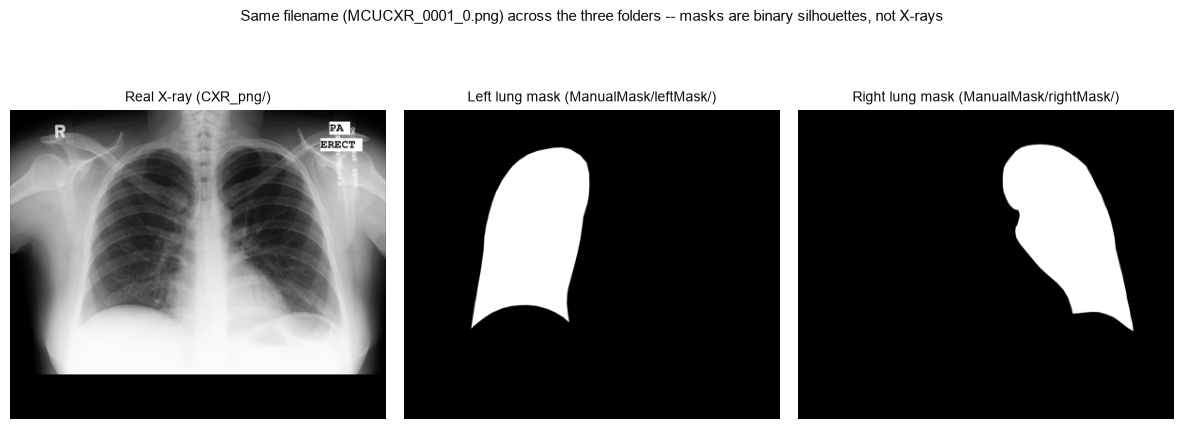

This is exactly why an unrestricted rglob is dangerous: same filename convention,
completely different content. Always scan CXR_png/ specifically for this dataset.


In [ ]:
# Visual proof: a "CXR" pulled from ManualMask is a binary silhouette, not an X-ray.
left_mask_dir = MONTGOMERY_DIR / "ManualMask" / "leftMask"
right_mask_dir = MONTGOMERY_DIR / "ManualMask" / "rightMask"
sample_id = cxr_pngs[0].name  # same filename should exist in both mask folders

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
titles_paths = [
    ("Real X-ray (CXR_png/)", cxr_pngs[0]),
    ("Left lung mask (ManualMask/leftMask/)", left_mask_dir / sample_id),
    ("Right lung mask (ManualMask/rightMask/)", right_mask_dir / sample_id),
]
for ax, (title, p) in zip(axes, titles_paths):
    if p.exists():
        ax.imshow(load_rgb(p, max_side=400), cmap="gray")
    else:
        ax.text(0.5, 0.5, "file not found", ha="center", va="center", transform=ax.transAxes)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
fig.suptitle(f"Same filename ({sample_id}) across the three folders -- masks are binary silhouettes, not X-rays", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()

print("This is exactly why an unrestricted rglob is dangerous: same filename convention,")
print("completely different content. Always scan CXR_png/ specifically for this dataset.")

## 2. Parse labels from the (correct) CXR_png file list

In [ ]:
records = []
for p in cxr_pngs:
    parts = p.stem.split("_")
    if len(parts) < 3:
        print(f"[WARN] Unexpected filename pattern, skipping: {p.name}")
        continue
    pid = f"MCU_{parts[1]}"
    lbl_code = parts[2]
    label = "tuberculosis" if lbl_code == "1" else "normal"
    records.append({"filepath": p, "label": label, "patient_id": pid})

df = pd.DataFrame(records)
print(f"Parsed {len(df)} real Montgomery X-ray records (expect 138).")
df.head()

Parsed 138 real Montgomery X-ray records (expect 138).


,filepath,label,patient_id
0,..\data\raw\pulmonary_abnormalities\Montgomery...,normal,MCU_0001
1,..\data\raw\pulmonary_abnormalities\Montgomery...,normal,MCU_0002
2,..\data\raw\pulmonary_abnormalities\Montgomery...,normal,MCU_0003
3,..\data\raw\pulmonary_abnormalities\Montgomery...,normal,MCU_0004
4,..\data\raw\pulmonary_abnormalities\Montgomery...,normal,MCU_0005


## 3. Class distribution

Unlike Shenzhen's near-1:1 balance, Montgomery skews normal-heavy. Combined with
its small absolute size (138 images total), TB-class metrics computed on this set
will have wide confidence intervals — expected and should be reported honestly,
not smoothed over.

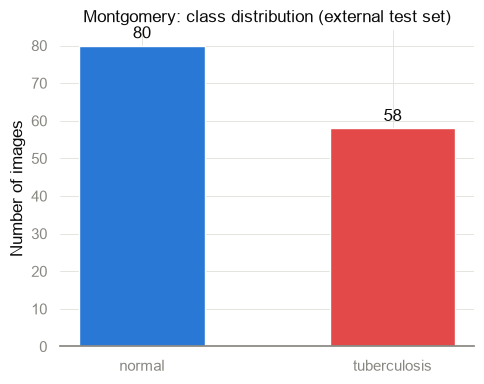

label
normal          80
tuberculosis    58
Name: count, dtype: int64
Balance ratio: 1.38x

Total external TB images: 58 -- small n, expect wide bootstrap CIs.


In [ ]:
counts = df["label"].value_counts().reindex(["normal", "tuberculosis"])

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index, counts.values, color=[PALETTE["blue"], PALETTE["red"]], width=0.5)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v}", ha="center", va="bottom", color=INK)
ax.set_ylabel("Number of images")
ax.set_title("Montgomery: class distribution (external test set)")
ax.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()
print(counts)
print(f"Balance ratio: {counts.max()/counts.min():.2f}x")
print(f"\nTotal external TB images: {counts['tuberculosis']} -- small n, expect wide bootstrap CIs.")

## 4. Patient-level check

In [ ]:
dupe_patients = df["patient_id"].value_counts()
print(f"Unique patient IDs: {df['patient_id'].nunique()}  |  Total images: {len(df)}")
print(f"Patients with >1 image: {(dupe_patients > 1).sum()}")
print("--> One image per patient, consistent with Shenzhen. Since this whole source")
print("    is held out as external test, patient-level leakage is a non-issue here")
print("    by construction -- the real risk was the mask-file contamination above,")
print("    not patient overlap.")

Unique patient IDs: 138  |  Total images: 138
Patients with >1 image: 0
--> One image per patient, consistent with Shenzhen. Since this whole source
    is held out as external test, patient-level leakage is a non-issue here
    by construction -- the real risk was the mask-file contamination above,
    not patient overlap.


## 5. Image dimensions & aspect ratio, vs. Shenzhen

Same acquisition family (NLM/NIH digitized PACS film) as Shenzhen, but a different
country/hospital — comparing resolution profiles helps judge how "different" the
external domain really is at the pixel-statistics level, beyond just the label
distribution.

In [ ]:
sizes = []
for p in df["filepath"]:
    with Image.open(p) as im:
        sizes.append(im.size)
df["width"] = [s[0] for s in sizes]
df["height"] = [s[1] for s in sizes]
df["aspect_ratio"] = df["width"] / df["height"]
print(df[["width", "height", "aspect_ratio"]].describe())

             width       height  aspect_ratio
count   138.000000   138.000000    138.000000
mean   4279.072464  4632.927536      0.939154
std     399.939642   399.939642      0.181241
min    4020.000000  4020.000000      0.821750
25%    4020.000000  4020.000000      0.821750
50%    4020.000000  4892.000000      0.821750
75%    4892.000000  4892.000000      1.216915
max    4892.000000  4892.000000      1.216915

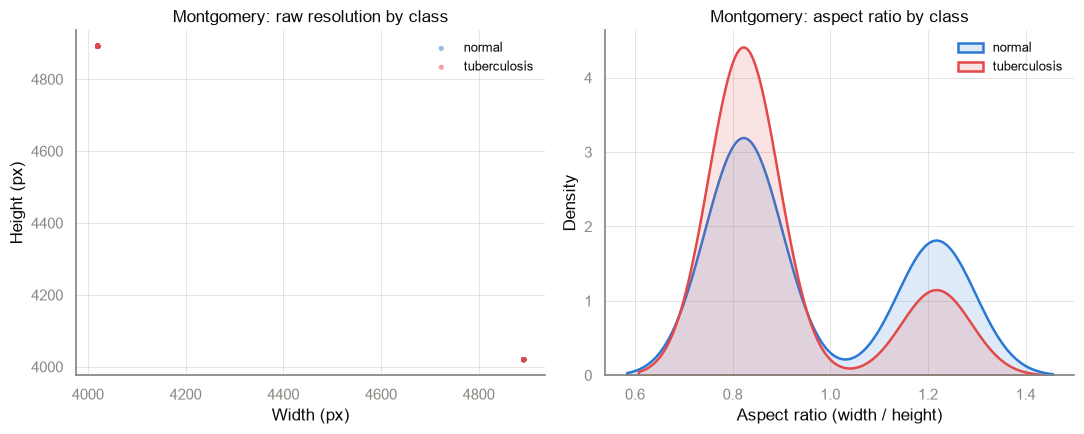

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for lbl, color in zip(["normal", "tuberculosis"], [PALETTE["blue"], PALETTE["red"]]):
    subset = df[df["label"] == lbl]
    axes[0].scatter(subset["width"], subset["height"], s=14, alpha=0.5, color=color, label=lbl, edgecolors="none")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title("Montgomery: raw resolution by class")
axes[0].legend(frameon=False, fontsize=9)

for lbl, color in zip(["normal", "tuberculosis"], [PALETTE["blue"], PALETTE["red"]]):
    subset = df[df["label"] == lbl]
    sns.kdeplot(subset["aspect_ratio"], ax=axes[1], color=color, label=lbl, fill=True, alpha=0.15, linewidth=1.8)
axes[1].set_xlabel("Aspect ratio (width / height)")
axes[1].set_title("Montgomery: aspect ratio by class")
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## 6. Pixel intensity distributions

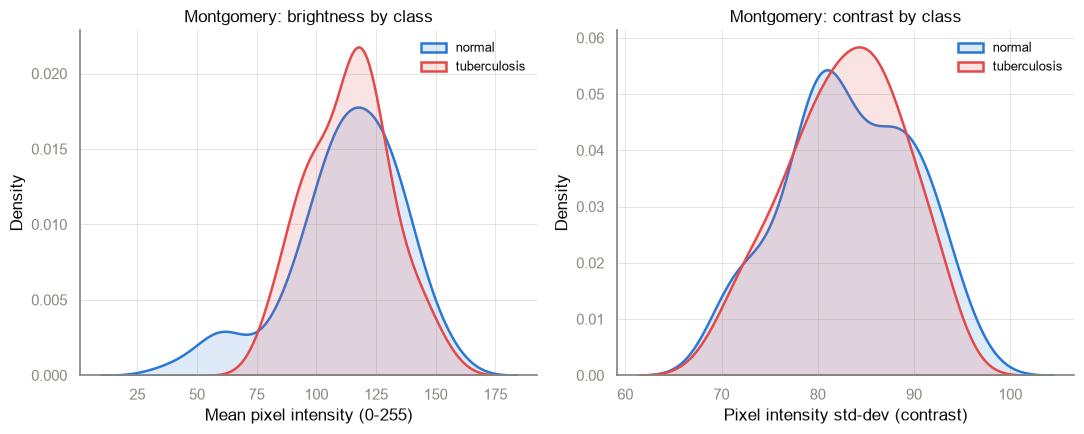

In [ ]:
def grayscale_stats(paths):
    means, stds = [], []
    for p in paths:
        arr = np.array(Image.open(p).convert("L"), dtype=np.float32)
        means.append(arr.mean())
        stds.append(arr.std())
    return np.array(means), np.array(stds)

stats_by_label = {lbl: grayscale_stats(df[df["label"] == lbl]["filepath"]) for lbl in ["normal", "tuberculosis"]}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for lbl, color in zip(["normal", "tuberculosis"], [PALETTE["blue"], PALETTE["red"]]):
    means, _ = stats_by_label[lbl]
    sns.kdeplot(means, ax=axes[0], color=color, label=lbl, fill=True, alpha=0.15, linewidth=1.8)
axes[0].set_xlabel("Mean pixel intensity (0-255)")
axes[0].set_title("Montgomery: brightness by class")
axes[0].legend(frameon=False, fontsize=9)

for lbl, color in zip(["normal", "tuberculosis"], [PALETTE["blue"], PALETTE["red"]]):
    _, stds = stats_by_label[lbl]
    sns.kdeplot(stds, ax=axes[1], color=color, label=lbl, fill=True, alpha=0.15, linewidth=1.8)
axes[1].set_xlabel("Pixel intensity std-dev (contrast)")
axes[1].set_title("Montgomery: contrast by class")
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## 7. Sample images per class

With only 58 TB images total in this set, look at all of them mentally as "this is
the entire external evidence base for the TB external-validation number" — small
external sets are normal in medical imaging research, but it's worth seeing the
full diversity (or lack thereof) directly.

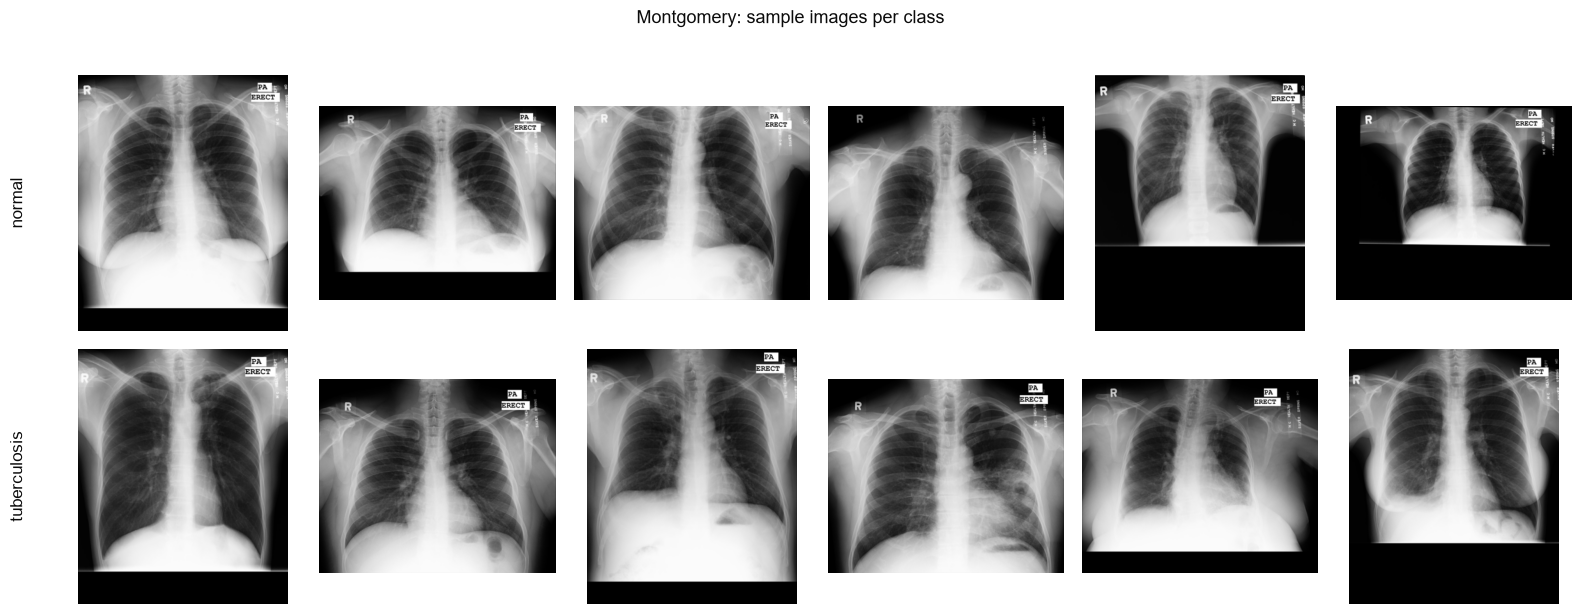

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for row, lbl in enumerate(["normal", "tuberculosis"]):
    n_show = min(6, len(df[df["label"] == lbl]))
    sample_paths = df[df["label"] == lbl]["filepath"].sample(n=n_show, random_state=RNG_SEED).tolist()
    for col, p in enumerate(sample_paths):
        img = load_rgb(p, max_side=400)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
    for col in range(n_show, 6):
        axes[row, col].axis("off")
    axes[row, 0].text(-0.25, 0.5, lbl, transform=axes[row, 0].transAxes,
                       ha="right", va="center", fontsize=12, color=INK, rotation=90)
fig.suptitle("Montgomery: sample images per class", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Summary — what we learned & how this dataset is used

**Findings:**
- Only 138 *real* X-ray images exist in this dataset (80 normal / 58 TB) — the
  `ManualMask/` subfolders contain 138 + 138 additional PNGs (left/right lung
  masks) that share the same filename pattern and **must be excluded** by
  scanning `CXR_png/` specifically. This was an actual bug found and fixed in
  `src/data/prepare.py` (`parse_pulmonary()`), independently reconfirmed here.
- Class balance skews normal-heavy (80 vs 58), and the small absolute size means
  TB metrics on this set will have wide bootstrap confidence intervals — report
  them as such, don't over-interpret point estimates.
- One image per patient; no within-source leakage risk.

**How this dataset is used downstream:**
1. **External / held-out test set for the `Tuberculosis` class only** — never
   seen during training or model selection. This is the number that tells us
   whether the model learned "tuberculosis" or just "Shenzhen's hospital."
2. Directly informs the domain-confound discussion (`CLAUDE.md` §4.3): an honest
   drop from Shenzhen-validation performance to Montgomery-external performance
   is the *expected and correct* result, not a failure to fix.
3. Given the small n (138), also worth reporting per-class metrics with bootstrap
   95% CIs rather than a single point estimate, per `CLAUDE.md` §4.4.